In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\processed\train_features.csv')
print(f"Loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(df.head())

C:\Users\gulna\AppData\Local\Temp\ipykernel_11260\1033794781.py:6: DtypeWarning: Columns (7,22,23,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\gulna\demand-forecasting-cloud\data\processed\train_features.csv')


Loaded: (100000, 82)
Columns: 82
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType  ...  sales_ma_14  sales_std_14  customers_ma_14  \
0              1         c  ...  5263.000000      0.000000       555.000000   
1              1         a  ...  5141.500000    171.826948       550.500000   
2              1         a  ...  5021.666667    240.504331       541.333333   
3              1         c  ...  5019.000000    196.443376       546.000000   
4              1         a  ...  5235.600000    513.342283       559.200000   

   sales_ma_30  s

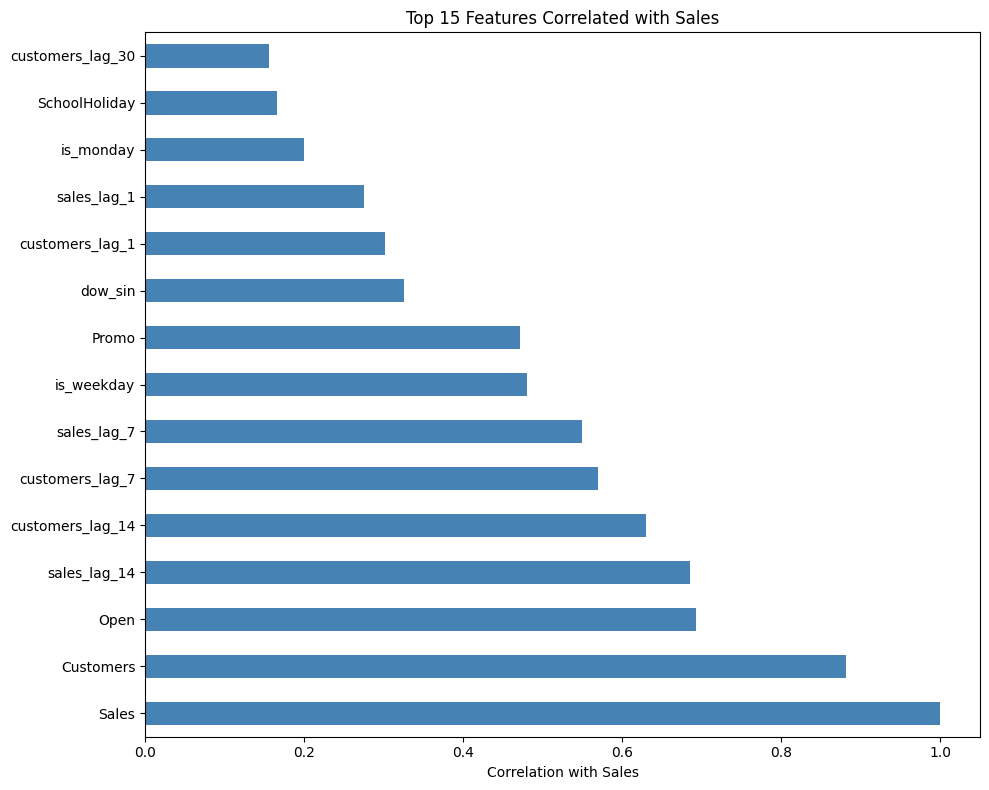

Top 15 features:
Sales               1.000000
Customers           0.881677
Open                0.692540
sales_lag_14        0.685170
customers_lag_14    0.630226
customers_lag_7     0.569605
sales_lag_7         0.550044
is_weekday          0.479955
Promo               0.471486
dow_sin             0.325713
customers_lag_1     0.301420
sales_lag_1         0.275351
is_monday           0.200145
SchoolHoliday       0.166349
customers_lag_30    0.155520
Name: Sales, dtype: float64
05_feature_correlation.png saved


In [2]:
# Top features by correlation 
df_numeric = df.select_dtypes(include=[np.number])
correlations = df_numeric.corr()['Sales'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Correlation with Sales')
ax.set_title('Top 15 Features Correlated with Sales')
plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\05_feature_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 15 features:")
print(correlations.head(15))

print("05_feature_correlation.png saved")

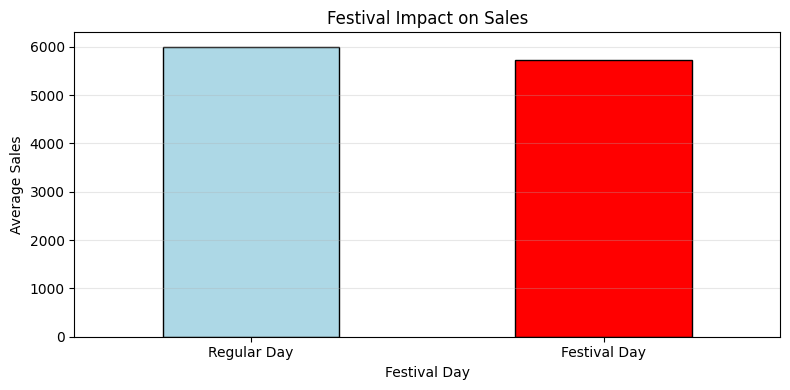


Festival Impact:
  Regular day avg: $6000.41
  Festival day avg: $5733.65
  Increase: +-4.4%
06_festival_impact.png saved


In [3]:
# Festival impact
festival_impact = df.groupby('is_festival')['Sales'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
festival_impact.plot(kind='bar', ax=ax, color=['lightblue', 'red'], edgecolor='black')
ax.set_xlabel('Festival Day')
ax.set_ylabel('Average Sales')
ax.set_title('Festival Impact on Sales')
ax.set_xticklabels(['Regular Day', 'Festival Day'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\06_festival_impact.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nFestival Impact:")
print(f"  Regular day avg: ${festival_impact[0]:.2f}")
print(f"  Festival day avg: ${festival_impact[1]:.2f}")
increase = ((festival_impact[1]/festival_impact[0])-1)*100
print(f"  Increase: +{increase:.1f}%")

print("06_festival_impact.png saved")

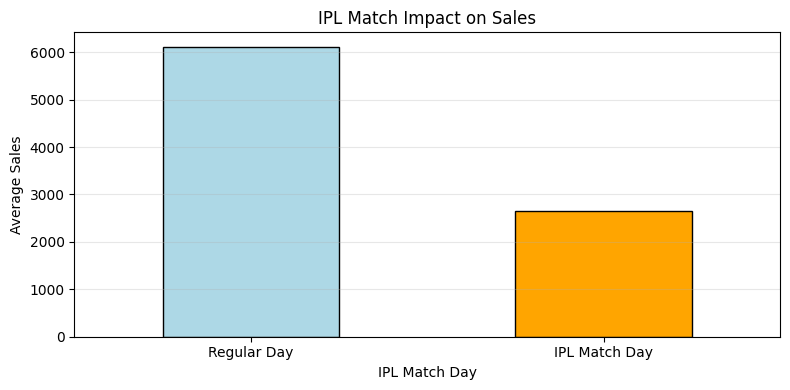


IPL Match Impact:
  Regular day avg: $6113.02
  IPL match day avg: $2657.66
  Increase: +-56.5%
07_ipl_impact.png saved


In [4]:
# IPL match impact
ipl_impact = df.groupby('is_ipl_match')['Sales'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ipl_impact.plot(kind='bar', ax=ax, color=['lightblue', 'orange'], edgecolor='black')
ax.set_xlabel('IPL Match Day')
ax.set_ylabel('Average Sales')
ax.set_title('IPL Match Impact on Sales')
ax.set_xticklabels(['Regular Day', 'IPL Match Day'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(r'C:\Users\gulna\demand-forecasting-cloud\results\07_ipl_impact.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nIPL Match Impact:")
print(f"  Regular day avg: ${ipl_impact[0]:.2f}")
print(f"  IPL match day avg: ${ipl_impact[1]:.2f}")
increase_ipl = ((ipl_impact[1]/ipl_impact[0])-1)*100
print(f"  Increase: +{increase_ipl:.1f}%")

print("07_ipl_impact.png saved")

In [5]:
# Summary
print(f"Total features created: {len(df.columns)}")
print(f"Total rows: {len(df):,}")
print(f"Numeric features: {len(df_numeric.columns)}")
print(f"\nTop 10 Features by Correlation:")
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"  {i:2d}. {feat:30s} → {corr:7.4f}")


Total features created: 82
Total rows: 100,000
Numeric features: 74

Top 10 Features by Correlation:
   1. Sales                          →  1.0000
   2. Customers                      →  0.8817
   3. Open                           →  0.6925
   4. sales_lag_14                   →  0.6852
   5. customers_lag_14               →  0.6302
   6. customers_lag_7                →  0.5696
   7. sales_lag_7                    →  0.5500
   8. is_weekday                     →  0.4800
   9. Promo                          →  0.4715
  10. dow_sin                        →  0.3257
